---세션 다시 시작 및 모든 셀 실행---

노트북을 처음부터 다시 실행하려면 Colab 메뉴에서 **런타임(Runtime) > 모두 실행(Run all)**을 선택하세요.


In [ ]:
# 한글 폰트 및 Matplotlib 설정 (Colab/Windows/Linux 공통)
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd

if 'google.colab' in sys.modules:
    nanum_path = Path('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf')
    if not nanum_path.exists():
        subprocess.run(['apt-get', 'update', '-qq'], check=False)
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False)

font_candidates = [
    Path('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'),
    Path('C:/Windows/Fonts/malgun.ttf'),
    Path('/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'),
]
font_path = next((path for path in font_candidates if path.exists()), None)
if font_path:
    fm.fontManager.addfont(str(font_path))
    font_name = fm.FontProperties(fname=str(font_path)).get_name()
    plt.rcParams['font.family'] = font_name
    print(f'✅ 한글 폰트 설정 완료: {font_name}')
else:
    print('ℹ️ 한글 폰트를 찾지 못해 기본 폰트를 사용합니다.')
plt.rcParams['axes.unicode_minus'] = False


In [ ]:
# 데이터 자동 로드: 같은 폴더 → 저장소 경로 → Colab → GitHub 원본 순서
from pathlib import Path
from urllib.parse import quote

DATA_FILENAME = '한국인터넷진흥원_침해사고 공격 IoC 지표_20260211.csv'
candidate_paths = [
    Path(DATA_FILENAME),
    Path('submissions/1st_year/김성준') / DATA_FILENAME,
    Path('/content') / DATA_FILENAME,
]
DATA_PATH = next((path for path in candidate_paths if path.exists()), None)

if DATA_PATH is not None:
    df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
    print(f'✅ 로컬 데이터 로드 완료: {DATA_PATH}')
else:
    encoded_name = quote(DATA_FILENAME)
    DATA_URL = (
        'https://raw.githubusercontent.com/Ayin0102/Daegun26Veritas/main/'
        f'submissions/1st_year/%EA%B9%80%EC%84%B1%EC%A4%80/{encoded_name}'
    )
    try:
        df = pd.read_csv(DATA_URL, encoding='utf-8-sig')
        DATA_PATH = DATA_URL
        print('✅ GitHub에서 데이터 로드 완료')
    except Exception as error:
        raise FileNotFoundError(
            f'{DATA_FILENAME}을 찾지 못했습니다. 노트북과 같은 폴더에 CSV를 두세요.'
        ) from error

df.columns = df.columns.str.replace('\ufeff', '', regex=False).str.strip()
required_columns = {'날짜', '공격 IP', '공격 IP 국가', '수행 행위'}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f'필수 컬럼이 없습니다: {sorted(missing_columns)}')

df['날짜'] = pd.to_datetime(df['날짜'], errors='coerce')
df = df.dropna(subset=['날짜']).copy()
df['월'] = df['날짜'].dt.strftime('%Y-%m')
print(f'데이터 크기: {df.shape[0]:,}행 × {df.shape[1]}열')
display(df.head())


### 유사한 공격 유형 의미론적 그룹화

'수행 행위' 컬럼의 범주를 단순화하고 해석 가능성을 높이기 위해 의미론적으로 유사한 공격 유형을 그룹화하겠습니다. 예를 들어, 'SQL Injection', '원격 접근', '무차별 대입 공격', '악성 파일 접근', '계정 탈취', '피싱'과 관련된 다양한 구문들을 더 일반적인 단일 범주로 통합할 수 있습니다. 이는 빈도에 따른 필터링을 하기 전에 더 넓은 공격 패턴을 이해하는 데 도움이 됩니다.

In [ ]:
import pandas as pd

# 유사한 행동을 공통 카테고리로 매핑하기 위한 딕셔너리 업데이트
# '무작위 대입 공격'과 '불법 광고 게시글 업로드' 등을 추가로 매핑
attack_type_mapping = {
    'SQL Injection': 'SQL Injection',
    'SQL Injection 시도': 'SQL Injection',
    'SQL Injection 공격': 'SQL Injection',
    'SQL 인젝션 공격': 'SQL Injection',
    'SQL Injection 공격 수행': 'SQL Injection',
    '블라인드 SQL Injection': 'SQL Injection',

    'RDP 연결': 'Remote Access',
    'RDP 접근': 'Remote Access',
    'RDP 접근 시도': 'Remote Access',
    '원격 접속': 'Remote Access',

    '무차별 대입 공격': 'Brute Force Attack',
    '무차별 대입 공격 시도': 'Brute Force Attack',
    'phpmyadmin 무작위 대입 공격': 'Brute Force Attack',
    '무작위 대입 공격': 'Brute Force Attack', # 통합
    'xmlrpc 무차별 대입 공격': 'Brute Force Attack',

    '악성 파일 접근': 'Malicious File Access',
    '악성 파일 유포지': 'Malicious File Access',
    '악성파일 유포지': 'Malicious File Access',

    '관리자 계정 로그인': 'Account Credential Access',
    '관리자 계정 로그인 및 정보 유출': 'Account Credential Access',
    '관리자 페이지 접근': 'Account Credential Access',
    'phpMyAdmin 로그인 시도': 'Account Credential Access',
    '웹메일 로그인': 'Account Credential Access',

    '피싱 메일 발송지': 'Phishing Related',
    '피싱 메일 발신지': 'Phishing Related',

    'C2 서버': 'C2 Server',
    '웹셸 접근': 'Webshell Access',
    'PHP 정보 노출 페이지 접근': 'PHP Info Disclosure Access',
    '악성코드 유포': 'Malicious Code Distribution',
    '불법 광고 게시글 업로드': 'Other', # 기타로 명시적 매핑
    '기타': 'Other'
}

# 매핑을 적용하여 새로운 그룹화된 컬럼 생성
df['수행 행위_semantic_grouped'] = df['수행 행위'].replace(attack_type_mapping)

print("\n의미론적 그룹화 완료 (Brute Force 통합):")
display(df['수행 행위_semantic_grouped'].value_counts().head(10))

### 의미론적 그룹화 후 낮은 빈도의 항목들을 '기타'로 통합

의미론적 그룹화를 거친 후에도 여전히 발생 횟수가 5회 미만인 '수행 행위' 항목들을 '기타' (Other) 카테고리로 통합하여 데이터를 더욱 간결하게 만들겠습니다.

In [ ]:
import numpy as np

# --- 1단계: 빈도수가 3 미만인 항목 제거 ---
semantic_action_counts_step1 = df['수행 행위_semantic_grouped'].value_counts()
low_freq_to_remove = semantic_action_counts_step1[semantic_action_counts_step1 < 3].index
df['수행 행위_semantic_grouped'] = df['수행 행위_semantic_grouped'].replace(low_freq_to_remove, np.nan)
df.dropna(subset=['수행 행위_semantic_grouped'], inplace=True)

# --- 2단계: 빈도수가 5 이하인 항목을 '기타'로 통합 ---
semantic_action_counts_step2 = df['수행 행위_semantic_grouped'].value_counts()
low_freq_to_other = semantic_action_counts_step2[semantic_action_counts_step2 <= 5].index
df['수행 행위_semantic_grouped'] = df['수행 행위_semantic_grouped'].replace(low_freq_to_other, '기타')

# 최종 빈도수 갱신
action_counts_after_filter = df['수행 행위_semantic_grouped'].value_counts()
print("\n최종 카테고리 분포 (통합 후):")
display(action_counts_after_filter)

In [ ]:
# 한글 폰트는 첫 번째 설정 셀에서 이미 구성했습니다.
print('✅ Matplotlib 한글 폰트 설정 유지')


### 국가별 가장 빈번한 공격 유형 분석

'공격 IP 국가'와 의미론적으로 그룹화된 '수행 행위'를 기준으로, 각 국가에서 가장 빈번하게 발생하는 공격 유형을 분석해 보겠습니다.

In [ ]:
# '공격 IP 국가'와 '수행 행위_semantic_grouped'를 기준으로 그룹화하고 발생 횟수 재계산
attack_by_country_type = df.groupby(['공격 IP 국가', '수행 행위_semantic_grouped']).size().reset_index(name='count')

# 각 국가별로 가장 빈번하게 발생하는 공격 유형 찾기
most_frequent_attack_per_country = attack_by_country_type.loc[attack_by_country_type.groupby('공격 IP 국가')['count'].idxmax()]

print("국가별 가장 빈번하게 발생하는 공격 유형 (통합 후):")
display(most_frequent_attack_per_country.sort_values(by='count', ascending=False).head(10))

### 1회만 기록된 국가들을 '기타_국가'로 통합

국가별 가장 빈번한 공격 유형 분석 결과에서 'count'가 1인 국가들을 '기타_국가'로 묶어 데이터를 간소화하고 전반적인 패턴을 더 명확하게 파악하겠습니다.

In [ ]:
# 'count'가 10 미만인 국가들을 '기타_국가'로 변경 (데이터 최신화)
most_frequent_attack_per_country['공격 IP 국가'] = (
    most_frequent_attack_per_country['공격 IP 국가'].where(
        most_frequent_attack_per_country['count'] >= 10,
        '기타_국가'
    )
)

# '기타_국가'로 변경된 항목들을 다시 그룹화하여 합계 계산
final_grouped_countries = most_frequent_attack_per_country.groupby(
    ['공격 IP 국가', '수행 행위_semantic_grouped']
)['count'].sum().reset_index()

# '기타_국가'를 최종 결과에서 제외
final_grouped_countries = final_grouped_countries[final_grouped_countries['공격 IP 국가'] != '기타_국가']

print("\n대시보드용 국가별 데이터 업데이트 완료:")
display(final_grouped_countries.sort_values(by='count', ascending=False).head(10))

### 상위 15개 '수행 행위' (Action Performed) 항목 선정

현재 DataFrame에서 가장 빈번하게 발생하는 '수행 행위' 상위 15개 항목을 선정하여 주요 공격 유형을 파악하겠습니다.

In [ ]:
# '수행 행위_semantic_grouped'의 각 항목별 발생 횟수 계산
action_counts_after_filter = df['수행 행위_semantic_grouped'].value_counts()

# 상위 15개 '수행 행위_semantic_grouped' 항목 선정
top_15_actions = action_counts_after_filter.head(15)

print("필터링 후 상위 15개 의미론적 그룹화된 '수행 행위' 항목:")
display(top_15_actions)

In [ ]:
# @title 📊 매트플롯립 사이버 위협 분석 대시보드 (시각화 전용) {display-mode: "form"}
import matplotlib.pyplot as plt
from matplotlib import gridspec
import seaborn as sns
import pandas as pd

# --- 1. 데이터 확인 및 준비 ---
# 이전 셀에서 생성된 df와 전처리된 컬럼을 사용합니다.
if 'df' in locals():
    # 레이아웃 설정 (constrained_layout=True로 여백 자동 조정)
    fig = plt.figure(figsize=(16, 12), facecolor='#f8fafc', constrained_layout=True)
    gs = gridspec.GridSpec(3, 2, height_ratios=[1, 4, 4], figure=fig)

    # A. KPI 영역 (상단)
    total_incidents = len(df)
    top_c = df['공격 IP 국가'].value_counts().index[0]
    # 의미론적 그룹화 컬럼 우선 사용
    target_col = '수행 행위_semantic_grouped' if '수행 행위_semantic_grouped' in df.columns else '수행 행위'
    top_a = df[target_col].value_counts().index[0]

    kpi_ax = fig.add_subplot(gs[0, :])
    kpi_ax.axis('off')
    kpi_text = f"총 사고 건수: {total_incidents:,}건  |  최다 공격국: {top_c}  |  주요 위협: {top_a}"
    kpi_ax.text(0.5, 0.5, kpi_text, fontsize=20, weight='bold', color='#1e293b', ha='center', va='center',
                bbox=dict(facecolor='white', alpha=0.9, edgecolor='#e2e8f0', boxstyle='round,pad=1'))

    # B. 월별 추이 (중단 전체)
    ax1 = fig.add_subplot(gs[1, :])
    if '월' not in df.columns:
        df['월'] = pd.to_datetime(df['날짜']).dt.strftime('%Y-%m')
    monthly_data = df.groupby('월').size()
    ax1.plot(monthly_data.index, monthly_data.values, marker='o', color='#3b82f6', linewidth=3, markersize=8, markerfacecolor='white')
    ax1.fill_between(monthly_data.index, monthly_data.values, color='#3b82f6', alpha=0.1)
    ax1.set_title('[월별 침해사고 발생 추이]', fontsize=16, pad=20, weight='bold')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # C. 국가별 상위 10 (하단 좌측)
    ax2 = fig.add_subplot(gs[2, 0])
    country_data = df['공격 IP 국가'].value_counts().head(10).sort_values()
    sns.barplot(x=country_data.values, y=country_data.index, hue=country_data.index, palette='Blues_d', ax=ax2, legend=False)
    ax2.set_title('[국가별 공격 현황 (Top 10)]', fontsize=14, pad=15, weight='bold')

    # D. 공격 유형 분포 (하단 우측)
    ax3 = fig.add_subplot(gs[2, 1])
    attack_data = df[target_col].value_counts().head(7)
    ax3.pie(attack_data.values, labels=attack_data.index, autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('pastel'), wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    ax3.set_title('[주요 공격 유형 분포]', fontsize=14, pad=15, weight='bold')

    plt.show()
else:
    print("❌ 데이터프레임(df)이 존재하지 않습니다. 상단 데이터 로드 셀을 먼저 실행해주세요.")

In [ ]:
# @title 🛡️ 사이버 위협 분석 통합 대시보드 (한글 깨짐 해결 버전) {display-mode: "form"}
import pandas as pd
import json
import os
from IPython.display import HTML

# 1. 데이터 로드 및 전처리
file_path = str(DATA_PATH)

if os.path.exists(file_path):
    # 최신 데이터프레임 사용
    if 'df' not in locals():
        df = pd.read_csv(file_path, encoding='utf-8')
        df['날짜'] = pd.to_datetime(df['날짜'])
        df['월'] = df['날짜'].dt.strftime('%Y-%m')

    # 통계 데이터
    total_count = len(df)
    country_counts = df['공격 IP 국가'].value_counts().head(10)
    top_country = country_counts.index[0]

    # 그룹화된 컬럼 우선 순위 적용
    target_col = '수행 행위_semantic_grouped' if '수행 행위_semantic_grouped' in df.columns else '수행 행위'
    attack_counts = df[target_col].value_counts().head(15)
    top_attack = attack_counts.index[0]

    # JSON 데이터 생성 (JS 전달용)
    trend_data = df.groupby('월').size().reset_index(name='count').to_json(orient='records')
    country_data = country_counts.reset_index().to_json(orient='records')
    attack_data = attack_counts.reset_index().to_json(orient='records')

    html_content = """
    <!DOCTYPE html>
    <html>
    <head>
        <meta charset="UTF-8">
        <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
        <link href="https://fonts.googleapis.com/css2?family=Pretendard:wght@400;700;900&display=swap" rel="stylesheet">
        <style>
            body { font-family: 'Pretendard', sans-serif; background: #f1f5f9; color: #1e293b; padding: 20px; }
            .dashboard { max-width: 1200px; margin: 0 auto; display: flex; flex-direction: column; gap: 20px; }
            .kpi-row { display: grid; grid-template-columns: repeat(3, 1fr); gap: 20px; }
            .card { background: #fff; padding: 25px; border-radius: 16px; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.1); border: 1px solid #e2e8f0; }
            .kpi-card { text-align: center; border-bottom: 5px solid #3b82f6; }
            .kpi-label { font-size: 0.9rem; color: #64748b; margin-bottom: 10px; font-weight: 600; }
            .kpi-value { font-size: 1.8rem; font-weight: 900; color: #3b82f6; }
            h2 { font-size: 1.2rem; margin-top: 0; display: flex; align-items: center; gap: 10px; }
            h2::before { content:''; display:inline-block; width:4px; height:18px; background:#3b82f6; border-radius:2px; }
            .chart-wrapper { position: relative; height: 320px; }
        </style>
    </head>
    <body>
        <div class="dashboard">
            <div class="kpi-row">
                <div class="card kpi-card"><div class="kpi-label">📊 총 탐지 건수</div><div class="kpi-value">TOTAL_VAL건</div></div>
                <div class="card kpi-card"><div class="kpi-label">🌍 최다 공격 국가</div><div class="kpi-value">COUNTRY_VAL</div></div>
                <div class="card kpi-card"><div class="kpi-label">⚔️ 핵심 공격 유형</div><div class="kpi-value" style="font-size:1.4rem">ATTACK_VAL</div></div>
            </div>
            <div class="card"><h2>📈 월별 침해사고 발생 추이</h2><div class="chart-wrapper"><canvas id="t"></canvas></div></div>
            <div style="display:grid; grid-template-columns: 1.2fr 0.8fr; gap:20px;">
                <div class="card"><h2>📍 국가별 탐지 현황 (Top 10)</h2><div class="chart-wrapper"><canvas id="c"></canvas></div></div>
                <div class="card"><h2>🍕 주요 공격 유형 분포</h2><div class="chart-wrapper"><canvas id="a"></canvas></div></div>
            </div>
        </div>
        <script>
            const commonOpt = { responsive: true, maintainAspectRatio: false, plugins: { legend: { labels: { font: { family: 'Pretendard' } } } } };
            const tD = JSON_TREND; const cD = JSON_COUNTRY; const aD = JSON_ATTACK;

            new Chart(document.getElementById('t'), { type: 'line', data: { labels: tD.map(x=>x['월']), datasets: [{ label: '건수', data: tD.map(x=>x.count), borderColor: '#3b82f6', backgroundColor: 'rgba(59, 130, 246, 0.1)', fill: true, tension: 0.4 }] }, options: commonOpt });
            new Chart(document.getElementById('c'), { type: 'bar', data: { labels: cD.map(x=>x['index']), datasets: [{ label: '건수', data: cD.map(x=>x['count']||x['공격 IP 국가']), backgroundColor: '#3b82f6' }] }, options: { ...commonOpt, indexAxis: 'y' } });
            new Chart(document.getElementById('a'), { type: 'doughnut', data: { labels: aD.map(x=>x['index']), datasets: [{ data: aD.map(x=>x['count']), backgroundColor: ['#3b82f6','#ef4444','#10b981','#f59e0b','#8b5cf6','#ec4899','#6366f1'] }] }, options: commonOpt });
        </script>
    </body>
    </html>
    """
    final_html = html_content.replace('TOTAL_VAL', f"{total_count:,}")\
                             .replace('COUNTRY_VAL', str(top_country))\
                             .replace('ATTACK_VAL', str(top_attack))\
                             .replace('JSON_TREND', trend_data)\
                             .replace('JSON_COUNTRY', country_data)\
                             .replace('JSON_ATTACK', attack_data)
    display(HTML(final_html))
else:
    print("❌ 파일을 찾을 수 없습니다.")

### 📈 월별 침해 사고 추이 분석

대시보드에 시계열 통찰력을 더하기 위해 월별 사고 발생 건수를 집계합니다.

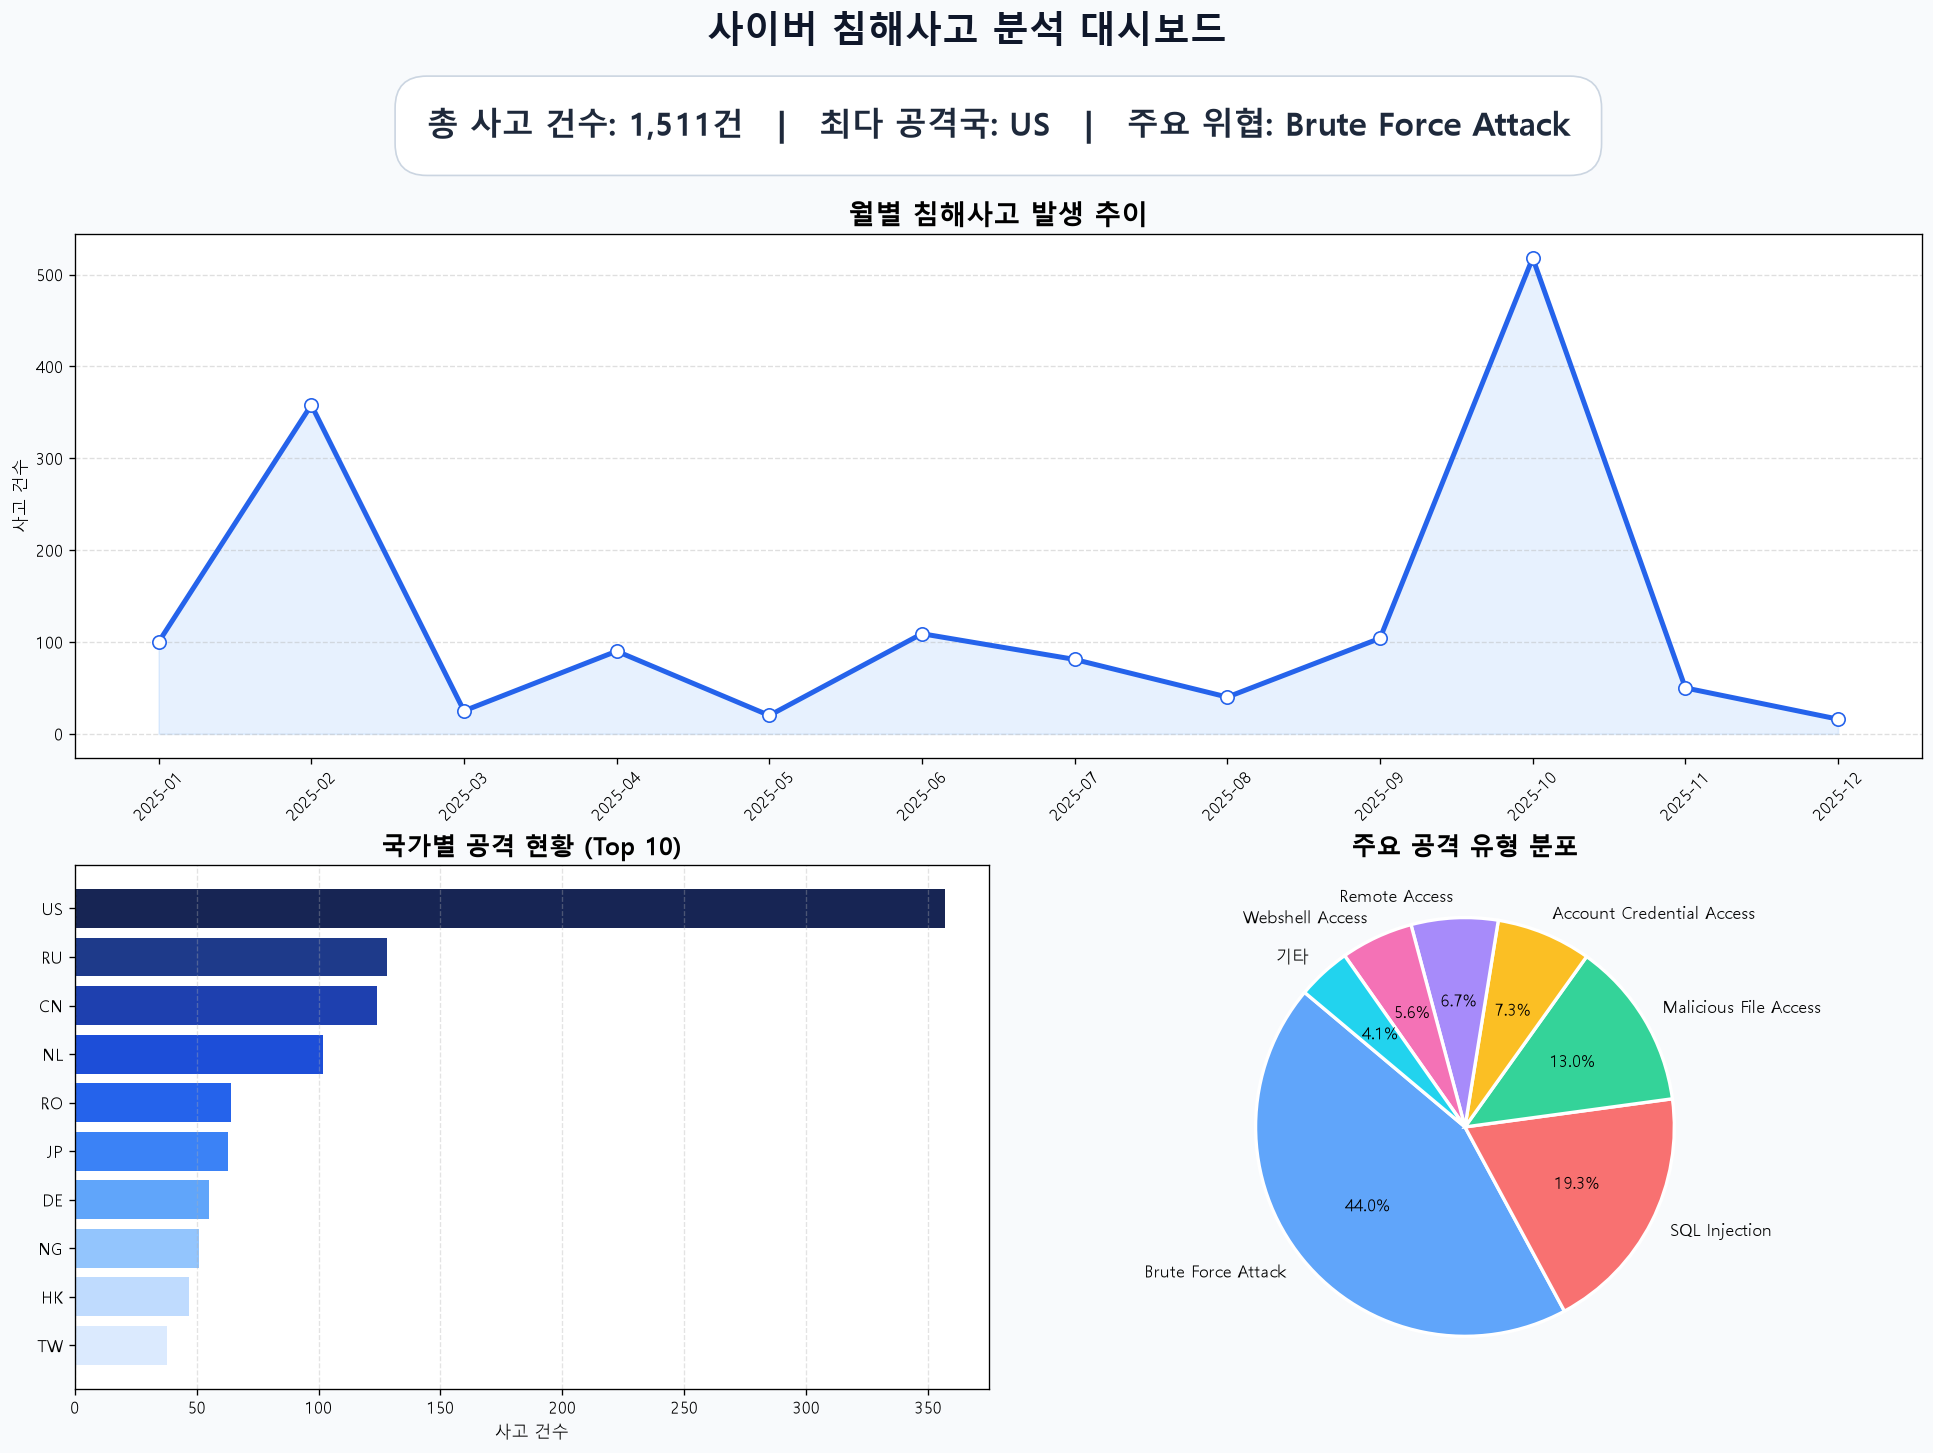

In [10]:
# @title 📊 최종 사이버 침해사고 분석 대시보드 (GitHub 호환) {display-mode: "form"}
import matplotlib.pyplot as plt
from matplotlib import gridspec

target_col = (
    '수행 행위_semantic_grouped'
    if '수행 행위_semantic_grouped' in df.columns
    else '수행 행위'
)
monthly_counts = df.groupby('월').size().sort_index()
country_counts = df['공격 IP 국가'].value_counts().head(10).sort_values()
attack_counts = df[target_col].value_counts().head(7)

fig = plt.figure(figsize=(16, 12), facecolor='#f8fafc', constrained_layout=True)
grid = gridspec.GridSpec(3, 2, height_ratios=[1, 4, 4], figure=fig)

kpi_ax = fig.add_subplot(grid[0, :])
kpi_ax.axis('off')
kpi_text = (
    f"총 사고 건수: {len(df):,}건   |   "
    f"최다 공격국: {df['공격 IP 국가'].value_counts().index[0]}   |   "
    f"주요 위협: {df[target_col].value_counts().index[0]}"
)
kpi_ax.text(
    0.5, 0.5, kpi_text, ha='center', va='center', fontsize=19,
    fontweight='bold', color='#1e293b',
    bbox=dict(boxstyle='round,pad=1', facecolor='white', edgecolor='#cbd5e1'),
)

trend_ax = fig.add_subplot(grid[1, :])
trend_ax.plot(
    monthly_counts.index, monthly_counts.values, marker='o',
    linewidth=3, color='#2563eb', markerfacecolor='white', markersize=8,
)
trend_ax.fill_between(
    range(len(monthly_counts)), monthly_counts.values, color='#60a5fa', alpha=0.15
)
trend_ax.set_title('월별 침해사고 발생 추이', fontsize=16, fontweight='bold')
trend_ax.set_ylabel('사고 건수')
trend_ax.tick_params(axis='x', rotation=45)
trend_ax.grid(axis='y', linestyle='--', alpha=0.4)

country_ax = fig.add_subplot(grid[2, 0])
country_ax.barh(
    country_counts.index,
    country_counts.values,
    color=['#dbeafe', '#bfdbfe', '#93c5fd', '#60a5fa', '#3b82f6',
           '#2563eb', '#1d4ed8', '#1e40af', '#1e3a8a', '#172554'],
)
country_ax.set_title('국가별 공격 현황 (Top 10)', fontsize=15, fontweight='bold')
country_ax.set_xlabel('사고 건수')
country_ax.grid(axis='x', linestyle='--', alpha=0.35)

attack_ax = fig.add_subplot(grid[2, 1])
attack_ax.pie(
    attack_counts.values, labels=attack_counts.index, autopct='%1.1f%%',
    startangle=140,
    colors=['#60a5fa', '#f87171', '#34d399', '#fbbf24', '#a78bfa', '#f472b6', '#22d3ee'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)
attack_ax.set_title('주요 공격 유형 분포', fontsize=15, fontweight='bold')

fig.suptitle(
    '사이버 침해사고 분석 대시보드',
    fontsize=22,
    fontweight='bold',
    color='#0f172a',
)
plt.show()
